In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from my_ml_kit import *
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GridSearchCV
# =========================
# Classification Models
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =========================
# Regression Models
# =========================

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [95]:
train_data = pd.read_csv("train.csv",na_values=['None', 'none', 'NULL', 'null'])
test_data = pd.read_csv("test.csv")
submission_data = pd.read_csv("sample_submission.csv")

In [18]:
train_data.head()

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [8]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  str    
 1   시술 시기 코드               256351 non-null  str    
 2   시술 당시 나이               256351 non-null  str    
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  str    
 5   특정 시술 유형               256349 non-null  str    
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  str    
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-null  int64  

In [24]:
train_data.isnull().sum()

ID                            0
시술 시기 코드                      0
시술 당시 나이                      0
임신 시도 또는 마지막 임신 경과 연수    246981
시술 유형                         0
                          ...  
난자 해동 경과일                254915
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
배아 해동 경과일                215982
임신 성공 여부                      0
Length: 69, dtype: int64

In [96]:
time_cols = [
    '임신 시도 또는 마지막 임신 경과 연수',
    '난자 해동 경과일',
    '난자 혼합 경과일',
    '배아 이식 경과일',
    '배아 해동 경과일',
]

for col in time_cols:
    train_data[f'{col}_performed'] = (
        train_data[col].notnull()
    ).astype(int)


train_data[time_cols] = train_data[time_cols].fillna(0)

In [97]:
train_data = train_data.fillna(0)

In [98]:
train_data.isnull().sum()

ID                                 0
시술 시기 코드                           0
시술 당시 나이                           0
임신 시도 또는 마지막 임신 경과 연수              0
시술 유형                              0
                                  ..
임신 시도 또는 마지막 임신 경과 연수_performed    0
난자 해동 경과일_performed                0
난자 혼합 경과일_performed                0
배아 이식 경과일_performed                0
배아 해동 경과일_performed                0
Length: 74, dtype: int64

In [99]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 74 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ID                               256351 non-null  str    
 1   시술 시기 코드                         256351 non-null  str    
 2   시술 당시 나이                         256351 non-null  str    
 3   임신 시도 또는 마지막 임신 경과 연수            256351 non-null  float64
 4   시술 유형                            256351 non-null  str    
 5   특정 시술 유형                         256351 non-null  object 
 6   배란 자극 여부                         256351 non-null  int64  
 7   배란 유도 유형                         256351 non-null  str    
 8   단일 배아 이식 여부                      256351 non-null  float64
 9   착상 전 유전 검사 사용 여부                 256351 non-null  float64
 10  착상 전 유전 진단 사용 여부                 256351 non-null  float64
 11  남성 주 불임 원인                       256351 non-null  int64  
 12  남성 부 불임 원인   

In [100]:
train_sub = train_data.copy()
X_sub = train_sub.drop(["임신 성공 여부","ID"],axis=1)
y_sub = train_sub["임신 성공 여부"]

In [101]:
binary_cols = []

for col in X_sub.columns:
    unique_values = set(X_sub[col].dropna().unique())

    if unique_values == {0, 1}:
        binary_cols.append(col)

X_sub[binary_cols] = X_sub[binary_cols].astype('category')

In [102]:
X_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 72 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   시술 시기 코드                         256351 non-null  str     
 1   시술 당시 나이                         256351 non-null  str     
 2   임신 시도 또는 마지막 임신 경과 연수            256351 non-null  float64 
 3   시술 유형                            256351 non-null  str     
 4   특정 시술 유형                         256351 non-null  object  
 5   배란 자극 여부                         256351 non-null  category
 6   배란 유도 유형                         256351 non-null  str     
 7   단일 배아 이식 여부                      256351 non-null  category
 8   착상 전 유전 검사 사용 여부                 256351 non-null  category
 9   착상 전 유전 진단 사용 여부                 256351 non-null  category
 10  남성 주 불임 원인                       256351 non-null  category
 11  남성 부 불임 원인                       256351 non-null  category
 12 

In [103]:
to_categorical_columns  = ["불임 원인 - 여성 요인","착상 전 유전 검사 사용 여부","PGD 시술 여부","PGS 시술 여부"]
X_sub[to_categorical_columns] = X_sub[to_categorical_columns].astype('category')
str_columns = X_sub.select_dtypes("str").columns
X_sub[str_columns] = X_sub[str_columns].astype('category')
X_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 72 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   시술 시기 코드                         256351 non-null  category
 1   시술 당시 나이                         256351 non-null  category
 2   임신 시도 또는 마지막 임신 경과 연수            256351 non-null  float64 
 3   시술 유형                            256351 non-null  category
 4   특정 시술 유형                         256351 non-null  object  
 5   배란 자극 여부                         256351 non-null  category
 6   배란 유도 유형                         256351 non-null  category
 7   단일 배아 이식 여부                      256351 non-null  category
 8   착상 전 유전 검사 사용 여부                 256351 non-null  category
 9   착상 전 유전 진단 사용 여부                 256351 non-null  category
 10  남성 주 불임 원인                       256351 non-null  category
 11  남성 부 불임 원인                       256351 non-null  category
 12 

In [72]:
categorical_columns = X_sub.select_dtypes("category").columns
numeric_columns = X_sub.select_dtypes("float64").columns

for cat_column in categorical_columns:
    print(f"{cat_column}의 고윳값 : \n {X_sub[cat_column].unique()} \n =====================================================")

시술 시기 코드의 고윳값 : 
 ['TRZKPL', 'TRYBLT', 'TRVNRY', 'TRJXFG', 'TRXQMD', 'TRCMWS', 'TRDQAZ']
Categories (7, str): ['TRCMWS', 'TRDQAZ', 'TRJXFG', 'TRVNRY', 'TRXQMD', 'TRYBLT', 'TRZKPL'] 
시술 당시 나이의 고윳값 : 
 ['만18-34세', '만45-50세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '알 수 없음']
Categories (7, str): ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음'] 
시술 유형의 고윳값 : 
 ['IVF', 'DI']
Categories (2, str): ['DI', 'IVF'] 
배란 자극 여부의 고윳값 : 
 [1, 0]
Categories (2, int64): [0, 1] 
배란 유도 유형의 고윳값 : 
 ['기록되지 않은 시행', '알 수 없음', '세트로타이드 (억제제)', '생식선 자극 호르몬']
Categories (4, str): ['기록되지 않은 시행', '생식선 자극 호르몬', '세트로타이드 (억제제)', '알 수 없음'] 
단일 배아 이식 여부의 고윳값 : 
 [0.0, 1.0]
Categories (2, float64): [0.0, 1.0] 
착상 전 유전 검사 사용 여부의 고윳값 : 
 [0.0, 1.0]
Categories (2, float64): [0.0, 1.0] 
착상 전 유전 진단 사용 여부의 고윳값 : 
 [0.0, 1.0]
Categories (2, float64): [0.0, 1.0] 
남성 주 불임 원인의 고윳값 : 
 [0, 1]
Categories (2, int64): [0, 1] 
남성 부 불임 원인의 고윳값 : 
 [0, 1]
Categories (2, int64): [0, 1] 
여성 주 불임 원인의 고윳값 : 
 

In [104]:
y_sub.value_counts()

임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

In [ ]:
print("Numeric Columns 단변량 분석\n")
for col in numeric_columns:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(
        train_sub[col],
        kde=True
    )
    plt.title(f'{col} Histogram')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(
        x=train_sub[col]
    )
    plt.title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

print("="*50)
print("categorical columns 단변량 분석\n")
for col in categorical_columns:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        x=train_sub[col],
        order=train_sub[col].value_counts().index
    )

    plt.title(f'{col} Countplot')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [36]:
categorical_features = X_sub.select_dtypes("category").columns
numeric_features = X_sub.select_dtypes("float64").columns

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [37]:
classification_basic_models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "knn_classifier": KNeighborsClassifier(),
    "decision_tree_classifier": DecisionTreeClassifier(random_state=42),
    "gaussian_nb": GaussianNB(),
}

In [38]:
data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

In [39]:
results, trained_pipes, predictions = run_model_candidates(
    models=classification_basic_models,
    preprocessor=preprocessor,
    **data_split,
    task_type="classification",
)

display(compare_results(results))

Running: logistic_regression
Running: knn_classifier
Running: decision_tree_classifier
Running: gaussian_nb


,name,task_type,cv_accuracy,cv_accuracy_std,cv_f1,cv_f1_std,cv_precision,cv_precision_std,cv_recall,cv_recall_std,cv_roc_auc,cv_roc_auc_std,test_accuracy,test_f1,test_precision,test_recall,test_roc_auc
0,gaussian_nb,classification,0.299829,0.004401,0.417624,0.001090,0.265967,0.000983,0.971726,0.003085,0.523364,0.004997,0.299585,0.418172,0.266220,0.974256,0.523180
1,decision_tree_classifier,classification,0.661113,0.000884,0.363046,0.003103,0.352861,0.002151,0.373844,0.004280,0.567708,0.001903,0.659008,0.352074,0.345781,0.358599,0.561172
2,knn_classifier,classification,0.704115,0.000914,0.316819,0.003866,0.392593,0.002818,0.265581,0.004456,0.649942,0.002655,0.705155,0.315756,0.394258,0.263325,0.648530
3,logistic_regression,classification,0.740272,0.001359,0.171455,0.002807,0.487620,0.012256,0.104016,0.001532,0.721137,0.001567,0.739833,0.167925,0.483303,0.101616,0.719246


In [105]:
count_cols = [
    '총 시술 횟수',
    'IVF 시술 횟수',
    'DI 시술 횟수',
    '총 임신 횟수',
    'IVF 임신 횟수',
    'DI 임신 횟수',
    '총 출산 횟수',
    'IVF 출산 횟수',
    'DI 출산 횟수',
]

count_map = {
    '0회': 0,
    '1회': 1,
    '2회': 2,
    '3회': 3,
    '4회': 4,
    '5회': 5,
    '6회 이상': 6,
}

# ordinal 변환
for col in count_cols:
    X_sub[col] = X_sub[col].map(count_map).astype(float)

# -----------------------------
# 성공률 feature
# -----------------------------

X_sub['총_임신_성공률'] = np.where(
    X_sub['총 시술 횟수'] == 0,
    0,
    X_sub['총 임신 횟수'] / X_sub['총 시술 횟수']
)

X_sub['IVF_임신_성공률'] = np.where(
    X_sub['IVF 시술 횟수'] == 0,
    0,
    X_sub['IVF 임신 횟수'] / X_sub['IVF 시술 횟수']
)

X_sub['DI_임신_성공률'] = np.where(
    X_sub['DI 시술 횟수'] == 0,
    0,
    X_sub['DI 임신 횟수'] / X_sub['DI 시술 횟수']
)

# -----------------------------
# 출산 전환률
# -----------------------------

X_sub['총_출산_전환률'] = np.where(
    X_sub['총 임신 횟수'] == 0,
    0,
    X_sub['총 출산 횟수'] / X_sub['총 임신 횟수']
)

X_sub['IVF_출산_전환률'] = np.where(
    X_sub['IVF 임신 횟수'] == 0,
    0,
    X_sub['IVF 출산 횟수'] / X_sub['IVF 임신 횟수']
)

X_sub['DI_출산_전환률'] = np.where(
    X_sub['DI 임신 횟수'] == 0,
    0,
    X_sub['DI 출산 횟수'] / X_sub['DI 임신 횟수']
)

# -----------------------------
# 실패 횟수
# -----------------------------

X_sub['총_실패_횟수'] = (
    X_sub['총 시술 횟수'] -
    X_sub['총 임신 횟수']
)

X_sub['IVF_실패_횟수'] = (
    X_sub['IVF 시술 횟수'] -
    X_sub['IVF 임신 횟수']
)

X_sub['DI_실패_횟수'] = (
    X_sub['DI 시술 횟수'] -
    X_sub['DI 임신 횟수']
)

# -----------------------------
# IVF 비중
# -----------------------------

X_sub['IVF_비중'] = np.where(
    X_sub['총 시술 횟수'] == 0,
    0,
    X_sub['IVF 시술 횟수'] / X_sub['총 시술 횟수']
)

X_sub['DI_비중'] = np.where(
    X_sub['총 시술 횟수'] == 0,
    0,
    X_sub['DI 시술 횟수'] / X_sub['총 시술 횟수']
)
X_sub['배아_이식률'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    X_sub['이식된 배아 수'] / X_sub['총 생성 배아 수']
)
X_sub['배아_저장률'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    X_sub['저장된 배아 수'] / X_sub['총 생성 배아 수']
)
X_sub['난자_배아_효율'] = np.where(
    X_sub['수집된 신선 난자 수'] == 0,
    0,
    X_sub['총 생성 배아 수'] / X_sub['수집된 신선 난자 수']
)
X_sub['총_배아_활용량'] = (
    X_sub['이식된 배아 수'] +
    X_sub['저장된 배아 수']
)
X_sub['배아이식_수행여부'] = (
    X_sub['이식된 배아 수'] > 0
).astype(int)
X_sub['고령여부'] = X_sub['시술 당시 나이'].isin([
    '만38-39세',
    '만40-42세',
    '만43-44세',
    '만45-50세'
]).astype(int)
X_sub['고령_이식배아_interaction'] = (
    X_sub['고령여부'] *
    X_sub['이식된 배아 수']
)
X_sub['고령_생성배아_interaction'] = (
    X_sub['고령여부'] *
    X_sub['총 생성 배아 수']
)
X_sub['고령_저장배아_interaction'] = (
    X_sub['고령여부'] *
    X_sub['저장된 배아 수']
)
X_sub['고령_난자수_interaction'] = (
    X_sub['고령여부'] *
    X_sub['수집된 신선 난자 수']
)
X_sub['고령_배아이식률_interaction'] = (
    X_sub['고령여부'] *
    X_sub['배아_이식률']
)

In [106]:
X_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 94 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   시술 시기 코드                         256351 non-null  category
 1   시술 당시 나이                         256351 non-null  category
 2   임신 시도 또는 마지막 임신 경과 연수            256351 non-null  float64 
 3   시술 유형                            256351 non-null  category
 4   특정 시술 유형                         256351 non-null  object  
 5   배란 자극 여부                         256351 non-null  category
 6   배란 유도 유형                         256351 non-null  category
 7   단일 배아 이식 여부                      256351 non-null  category
 8   착상 전 유전 검사 사용 여부                 256351 non-null  category
 9   착상 전 유전 진단 사용 여부                 256351 non-null  category
 10  남성 주 불임 원인                       256351 non-null  category
 11  남성 부 불임 원인                       256351 non-null  category
 12 

In [88]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

In [58]:
classification_basic_models = {
    "logistic_regression": LogisticRegression(max_iter=1000,class_weight='balanced'),
    # "knn_classifier": KNeighborsClassifier(),
    # "decision_tree_classifier": DecisionTreeClassifier(random_state=42),
    # "gaussian_nb": GaussianNB(),
}
data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)
results, trained_pipes, predictions = run_model_candidates(
    models=classification_basic_models,
    preprocessor=preprocessor,
    **data_split,
    task_type="classification",
)

display(compare_results(results))

Running: logistic_regression


,name,task_type,cv_accuracy,cv_accuracy_std,cv_f1,cv_f1_std,cv_precision,cv_precision_std,cv_recall,cv_recall_std,cv_roc_auc,cv_roc_auc_std,test_accuracy,test_f1,test_precision,test_recall,test_roc_auc
0,logistic_regression,classification,0.616706,0.001842,0.508916,0.001469,0.38036,0.001341,0.768752,0.003204,0.727393,0.001486,0.616606,0.508292,0.380083,0.767024,0.72557


In [59]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

pipe = trained_pipes["logistic_regression"]

X_test = data_split["X_test"]
y_test = data_split["y_test"]

y_proba = pipe.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.01):
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
    })

df_threshold = pd.DataFrame(threshold_results)

df_threshold.sort_values("f1", ascending=False).head(10)

,threshold,accuracy,f1,precision,recall
38,0.48,0.598799,0.509935,0.372529,0.807942
37,0.47,0.589144,0.509306,0.368292,0.825306
39,0.49,0.608219,0.509175,0.376423,0.786577
36,0.46,0.580075,0.508335,0.364392,0.840254
40,0.50,0.616606,0.508292,0.380083,0.767024
41,0.51,0.625753,0.507849,0.384586,0.747395
35,0.45,0.571259,0.506865,0.360581,0.852861
42,0.52,0.635174,0.506451,0.389283,0.724521
34,0.44,0.562443,0.505598,0.357018,0.865997
43,0.53,0.644380,0.505358,0.394410,0.703156


In [60]:
best_threshold = df_threshold.sort_values("f1", ascending=False).iloc[0]["threshold"]
y_pred_best = (y_proba >= best_threshold).astype(int)

print("best_threshold:", best_threshold)
print("f1:", f1_score(y_test, y_pred_best))
print("precision:", precision_score(y_test, y_pred_best))
print("recall:", recall_score(y_test, y_pred_best))
print("accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

best_threshold: 0.47999999999999976
f1: 0.5099347214942583
precision: 0.37252854358117515
recall: 0.807942020232523
accuracy: 0.5987985410856039
[[19999 18026]
 [ 2544 10702]]
              precision    recall  f1-score   support

           0       0.89      0.53      0.66     38025
           1       0.37      0.81      0.51     13246

    accuracy                           0.60     51271
   macro avg       0.63      0.67      0.59     51271
weighted avg       0.75      0.60      0.62     51271



In [61]:
X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    class_weights=[1, 190123 / 66228]
)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0:	learn: 0.6819023	test: 0.6770126	best: 0.6770126 (0)	total: 3.81s	remaining: 1h 3m 30s
100:	learn: 0.7056148	test: 0.7002546	best: 0.7002546 (100)	total: 6.54s	remaining: 58.2s
200:	learn: 0.7091925	test: 0.7025008	best: 0.7026306 (198)	total: 10.3s	remaining: 41s
300:	learn: 0.7114259	test: 0.7032756	best: 0.7036709 (287)	total: 13.5s	remaining: 31.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7036709074
bestIteration = 287

Shrink model to first 288 iterations.
accuracy: 0.6219305260283591
f1: 0.5151575787893947
precision: 0.3852023640308222
recall: 0.7774422467159897
roc_auc: 0.7363219918870972
[[21589 16436]
 [ 2948 10298]]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.39      0.78      0.52     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271



In [62]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(30)

,feature,importance
13,num__이식된 배아 수,46.853565
15,num__저장된 배아 수,6.511848
147,cat__배아 이식 경과일_performed_1,6.018206
146,cat__배아 이식 경과일_performed_0,5.168263
10,num__총 생성 배아 수,3.884268
26,num__배아 이식 경과일,3.436179
108,cat__난자 출처_본인 제공,2.897558
46,cat__시술 당시 나이_만18-34세,2.628493
57,cat__배란 유도 유형_기록되지 않은 시행,2.176934
19,num__수집된 신선 난자 수,1.743102


In [89]:
data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    class_weights=[1, 190123 / 66228]
)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0:	learn: 0.6243432	test: 0.6205022	best: 0.6205022 (0)	total: 273ms	remaining: 4m 33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7050968218
bestIteration = 1

Shrink model to first 2 iterations.
accuracy: 0.5689181018509489
f1: 0.49825198637911466
precision: 0.3562524347487339
recall: 0.8284765212139514
roc_auc: 0.7166990305236974
[[18195 19830]
 [ 2272 10974]]
              precision    recall  f1-score   support

           0       0.89      0.48      0.62     38025
           1       0.36      0.83      0.50     13246

    accuracy                           0.57     51271
   macro avg       0.62      0.65      0.56     51271
weighted avg       0.75      0.57      0.59     51271



In [76]:
X_sub.columns[
    X_sub.columns.str.contains("interaction")
]

Index(['고령_이식배아_interaction', '고령_생성배아_interaction', '고령_저장배아_interaction',
       '고령_난자수_interaction', '고령_배아이식률_interaction'],
      dtype='str')

In [107]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6243432	test: 0.6205022	best: 0.6205022 (0)	total: 25.1ms	remaining: 25.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7050968218
bestIteration = 1

Shrink model to first 2 iterations.
f1: 0.49825198637911466
precision: 0.3562524347487339
recall: 0.8284765212139514
roc_auc: 0.7166990305236974


In [108]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
13,num__이식된 배아 수,54.689484
43,num__배아이식_수행여부,21.959834
119,cat__난자 출처_본인 제공,8.975926
40,num__배아_저장률,6.307058
48,num__고령_난자수_interaction,4.263210
26,num__배아 이식 경과일,1.771097
45,num__고령_이식배아_interaction,1.339023
30,num__DI_임신_성공률,0.568927
1,num__총 시술 횟수,0.116978
49,num__고령_배아이식률_interaction,0.008462


In [109]:
X_sub['배아_이식_집중도'] = np.where(
    (X_sub['이식된 배아 수'] + X_sub['저장된 배아 수']) == 0,
    0,
    X_sub['이식된 배아 수'] /
    (
        X_sub['이식된 배아 수'] +
        X_sub['저장된 배아 수']
    )
)
X_sub['미활용_배아수'] = (
    X_sub['총 생성 배아 수']
    - X_sub['이식된 배아 수']
    - X_sub['저장된 배아 수']
)
X_sub['배아_손실률'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    1 - (
        (
            X_sub['이식된 배아 수']
            + X_sub['저장된 배아 수']
        )
        / X_sub['총 생성 배아 수']
    )
)

In [110]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6951802	test: 0.6919228	best: 0.6919228 (0)	total: 2.03s	remaining: 33m 50s
100:	learn: 0.7055499	test: 0.7003657	best: 0.7004658 (99)	total: 4.9s	remaining: 43.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.701674265
bestIteration = 128

Shrink model to first 129 iterations.
f1: 0.5133903989588027
precision: 0.38400479257151415
recall: 0.7742714781820927
roc_auc: 0.734692594482023


In [111]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
13,num__이식된 배아 수,29.906172
50,num__배아_이식_집중도,16.128804
43,num__배아이식_수행여부,11.315173
48,num__고령_난자수_interaction,4.946968
122,cat__난자 출처_본인 제공,4.483695
19,num__수집된 신선 난자 수,3.173943
161,cat__배아 이식 경과일_performed_1,2.769594
26,num__배아 이식 경과일,2.566846
160,cat__배아 이식 경과일_performed_0,2.408714
71,cat__배란 유도 유형_기록되지 않은 시행,2.361368


In [112]:
X_sub['저장대비_이식비율'] = (
    X_sub['저장된 배아 수']
    / (X_sub['이식된 배아 수'] + 1)
)
X_sub['배아_활용효율'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    (
        X_sub['이식된 배아 수']
        + X_sub['저장된 배아 수']
    ) / X_sub['총 생성 배아 수']
)

In [113]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6931020	test: 0.6863425	best: 0.6863425 (0)	total: 727ms	remaining: 12m 6s
100:	learn: 0.7052699	test: 0.6989059	best: 0.6990648 (99)	total: 5.37s	remaining: 47.8s
200:	learn: 0.7094951	test: 0.7012277	best: 0.7014359 (198)	total: 9.8s	remaining: 39s
300:	learn: 0.7124711	test: 0.7023474	best: 0.7023474 (300)	total: 14.7s	remaining: 34.2s
400:	learn: 0.7151454	test: 0.7020501	best: 0.7024855 (377)	total: 20.6s	remaining: 30.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7027100555
bestIteration = 436

Shrink model to first 437 iterations.
f1: 0.5147040389099206
precision: 0.38530835929582224
recall: 0.7749509285822135
roc_auc: 0.7369680678662199


In [114]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
43,num__배아이식_수행여부,23.575989
50,num__배아_이식_집중도,11.736595
13,num__이식된 배아 수,11.727775
48,num__고령_난자수_interaction,5.030687
163,cat__배아 이식 경과일_performed_1,4.072863
124,cat__난자 출처_본인 제공,3.954627
39,num__배아_이식률,3.493936
19,num__수집된 신선 난자 수,2.798951
42,num__총_배아_활용량,2.520310
26,num__배아 이식 경과일,2.167861


In [116]:
X_raw = train_data.drop(["임신 성공 여부", "ID"], axis=1).copy()
y_raw = train_data["임신 성공 여부"].copy()

# 문자형 category 변환
str_columns = X_raw.select_dtypes(include="object").columns
X_raw[str_columns] = X_raw[str_columns].astype("category")

# 0/1 컬럼 category 변환
binary_cols = []

for col in X_raw.columns:
    unique_values = set(X_raw[col].dropna().unique())

    if unique_values == {0, 1}:
        binary_cols.append(col)

X_raw[binary_cols] = X_raw[binary_cols].astype("category")

# feature 분리
numeric_features_raw = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features_raw = X_raw.select_dtypes(include="category").columns.tolist()

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
categorical_features_raw = X_raw.select_dtypes(
    include="category"
).columns.tolist()

X_raw[categorical_features_raw] = (
    X_raw[categorical_features_raw]
    .astype(str)
)
preprocessor_raw = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_raw),
    ("cat", categorical_transformer, categorical_features_raw),
])
# =============================
# 같은 조건으로 split
# =============================

data_split_raw = make_data_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42,
)

X_train_raw = data_split_raw["X_train"]
X_test_raw = data_split_raw["X_test"]
y_train_raw = data_split_raw["y_train"]
y_test_raw = data_split_raw["y_test"]

X_train_raw_trans = preprocessor_raw.fit_transform(X_train_raw)
X_test_raw_trans = preprocessor_raw.transform(X_test_raw)
# =============================
# Raw CatBoost 학습
# =============================

cat_model_raw = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    class_weights=[1, 190123 / 66228]
)

cat_model_raw.fit(
    X_train_raw_trans,
    y_train_raw,
    eval_set=(X_test_raw_trans, y_test_raw),
    early_stopping_rounds=50
)

y_pred_raw = cat_model_raw.predict(X_test_raw_trans)
y_proba_raw = cat_model_raw.predict_proba(X_test_raw_trans)[:, 1]

print("RAW CatBoost")
print("accuracy:", accuracy_score(y_test_raw, y_pred_raw))
print("f1:", f1_score(y_test_raw, y_pred_raw))
print("precision:", precision_score(y_test_raw, y_pred_raw))
print("recall:", recall_score(y_test_raw, y_pred_raw))
print("roc_auc:", roc_auc_score(y_test_raw, y_proba_raw))

print(confusion_matrix(y_test_raw, y_pred_raw))
print(classification_report(y_test_raw, y_pred_raw))
feature_names_raw = preprocessor_raw.get_feature_names_out()

importance_raw_df = pd.DataFrame({
    "feature": feature_names_raw,
    "importance": cat_model_raw.feature_importances_
})

importance_raw_df.sort_values("importance", ascending=False).head(30)

/tmp/ipykernel_11104/2368487179.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_columns = X_raw.select_dtypes(include="object").columns


0:	learn: 0.6869417	test: 0.6825934	best: 0.6825934 (0)	total: 587ms	remaining: 9m 46s
100:	learn: 0.7057888	test: 0.7007905	best: 0.7007905 (100)	total: 3.85s	remaining: 34.3s
200:	learn: 0.7090193	test: 0.7029811	best: 0.7029811 (199)	total: 5.26s	remaining: 20.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7032244064
bestIteration = 206

Shrink model to first 207 iterations.
RAW CatBoost
accuracy: 0.6215599461683993
f1: 0.5147187554710753
precision: 0.3848599319295358
recall: 0.7768382908047713
roc_auc: 0.735265387697704
[[21578 16447]
 [ 2956 10290]]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.38      0.78      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271



,feature,importance
5,num__이식된 배아 수,39.032219
224,cat__배아 이식 경과일_performed_1,9.700350
7,num__저장된 배아 수,7.591511
223,cat__배아 이식 경과일_performed_0,7.580220
11,num__수집된 신선 난자 수,4.340361
18,num__배아 이식 경과일,4.049739
2,num__총 생성 배아 수,3.710358
66,cat__배란 유도 유형_알 수 없음,3.216248
27,cat__시술 당시 나이_만18-34세,2.846677
31,cat__시술 당시 나이_만43-44세,1.743760


In [117]:
drop_interaction_cols = [
    '고령_이식배아_interaction',
    '고령_생성배아_interaction',
    '고령_저장배아_interaction',
    '고령_배아이식률_interaction',
]

X_sub = X_sub.drop(columns=drop_interaction_cols, errors='ignore')

In [118]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

In [119]:
data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

In [120]:
X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6745564	test: 0.6669496	best: 0.6669496 (0)	total: 581ms	remaining: 9m 40s
100:	learn: 0.7052138	test: 0.6992234	best: 0.6993101 (95)	total: 4.39s	remaining: 39.1s
200:	learn: 0.7089520	test: 0.7011932	best: 0.7011932 (200)	total: 7.14s	remaining: 28.4s
300:	learn: 0.7119271	test: 0.7032654	best: 0.7032787 (296)	total: 10.8s	remaining: 25.1s
400:	learn: 0.7147540	test: 0.7030068	best: 0.7035602 (367)	total: 14.3s	remaining: 21.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7035602341
bestIteration = 367

Shrink model to first 368 iterations.
f1: 0.5155466399197592
precision: 0.3859728167004581
recall: 0.7760833459157481
roc_auc: 0.7367450389796759


In [121]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
46,num__배아_이식_집중도,22.433553
13,num__이식된 배아 수,18.674443
43,num__배아이식_수행여부,15.660574
45,num__고령_난자수_interaction,5.936923
120,cat__난자 출처_본인 제공,4.417757
15,num__저장된 배아 수,2.950326
159,cat__배아 이식 경과일_performed_1,2.565215
10,num__총 생성 배아 수,2.545588
26,num__배아 이식 경과일,2.274315
42,num__총_배아_활용량,1.597014


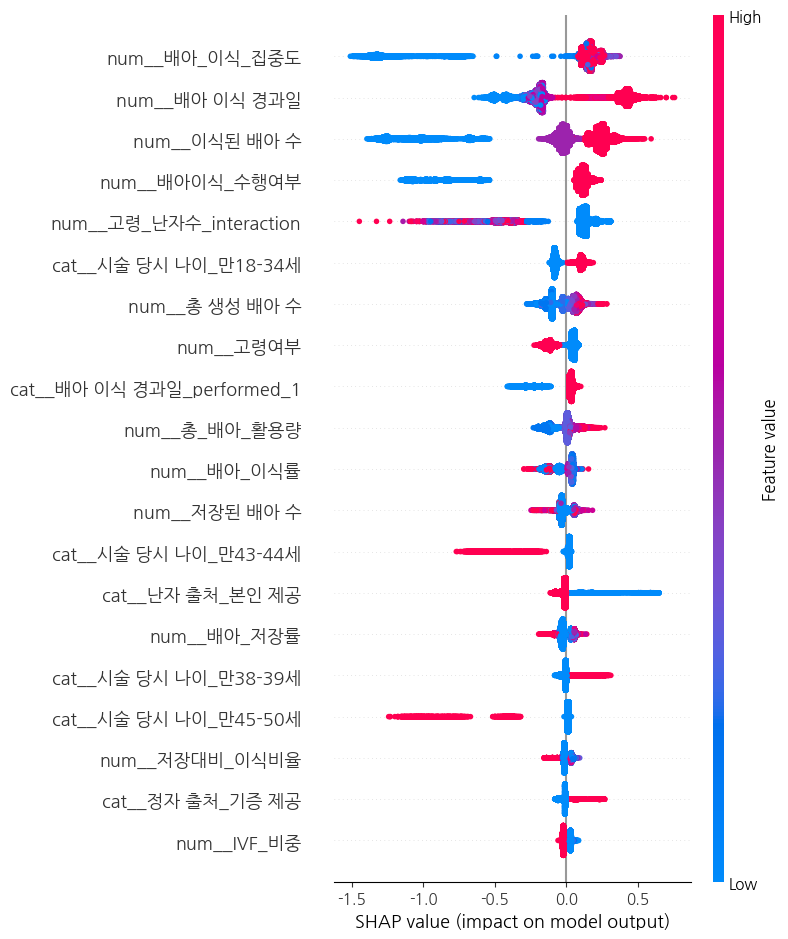

In [122]:
import shap

explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test_trans)

feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names
)

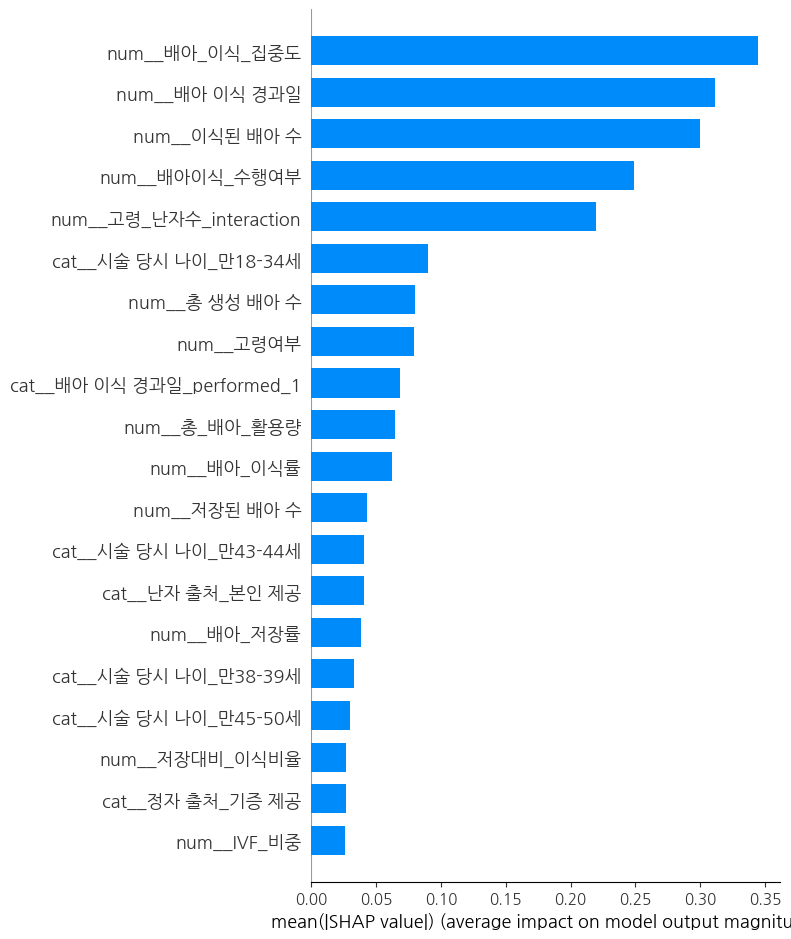

In [123]:
shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    plot_type="bar"
)

In [125]:
X_sub['배아_활용효율'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    (
        X_sub['이식된 배아 수']
        + X_sub['저장된 배아 수']
    ) / X_sub['총 생성 배아 수']
)
X_sub['미활용_배아수'] = (
    X_sub['총 생성 배아 수']
    - X_sub['이식된 배아 수']
    - X_sub['저장된 배아 수']
)
X_sub['배아_손실률'] = np.where(
    X_sub['총 생성 배아 수'] == 0,
    0,
    1 - (
        (
            X_sub['이식된 배아 수']
            + X_sub['저장된 배아 수']
        ) / X_sub['총 생성 배아 수']
    )
)
X_sub['저장대비_이식비율'] = (
    X_sub['저장된 배아 수']
    / (X_sub['이식된 배아 수'] + 1)
)
X_sub['배아_생성효율'] = np.where(
    X_sub['수집된 신선 난자 수'] == 0,
    0,
    X_sub['총 생성 배아 수']
    / X_sub['수집된 신선 난자 수']
)

In [126]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6765322	test: 0.6700329	best: 0.6700329 (0)	total: 5.46s	remaining: 1h 30m 57s
100:	learn: 0.7052018	test: 0.6995051	best: 0.6995051 (100)	total: 9.75s	remaining: 1m 26s
200:	learn: 0.7090845	test: 0.7011008	best: 0.7012149 (198)	total: 11.1s	remaining: 44.1s
300:	learn: 0.7120178	test: 0.7020758	best: 0.7023867 (279)	total: 12.3s	remaining: 28.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7023867326
bestIteration = 279

Shrink model to first 280 iterations.
f1: 0.5142685340615839
precision: 0.38485768927888403
recall: 0.7747999396044088
roc_auc: 0.7361671889733772


In [127]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
13,num__이식된 배아 수,23.350944
46,num__배아_이식_집중도,19.287831
43,num__배아이식_수행여부,14.134074
45,num__고령_난자수_interaction,5.455627
26,num__배아 이식 경과일,3.162050
121,cat__난자 출처_본인 제공,2.969669
49,num__저장대비_이식비율,2.948540
42,num__총_배아_활용량,2.844074
10,num__총 생성 배아 수,2.305515
15,num__저장된 배아 수,2.100473


In [129]:
process_cols = [
    '난자 해동 경과일_performed',
    '난자 혼합 경과일_performed',
    '배아 이식 경과일_performed',
    '배아 해동 경과일_performed'
]

X_sub[process_cols] = X_sub[process_cols].astype(int)

X_sub['시술_진행단계_수'] = (
    X_sub[process_cols]
    .sum(axis=1)
)
time_cols = [
    '난자 해동 경과일',
    '난자 혼합 경과일',
    '배아 이식 경과일',
    '배아 해동 경과일'
]

X_sub['총_시술_경과일'] = X_sub[time_cols].sum(axis=1)

X_sub['고위험_연령군'] = X_sub['시술 당시 나이'].isin([
    '만40-42세',
    '만43-44세',
    '만45-50세'
]).astype(int)

In [130]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6722192	test: 0.6670532	best: 0.6670532 (0)	total: 43.4ms	remaining: 43.4s
100:	learn: 0.7057932	test: 0.7006868	best: 0.7009002 (95)	total: 2.65s	remaining: 23.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7016402914
bestIteration = 143

Shrink model to first 144 iterations.
f1: 0.5132451159416664
precision: 0.38378661479181475
recall: 0.7744979616487996
roc_auc: 0.735209251762754


In [131]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
13,num__이식된 배아 수,28.714871
50,num__배아_이식_집중도,20.056707
47,num__배아이식_수행여부,9.364022
49,num__고령_난자수_interaction,5.900859
128,cat__난자 출처_본인 제공,4.003574
30,num__배아 이식 경과일_performed,2.989962
10,num__총 생성 배아 수,2.531994
56,num__시술_진행단계_수,2.446263
15,num__저장된 배아 수,2.318219
43,num__배아_이식률,2.011416


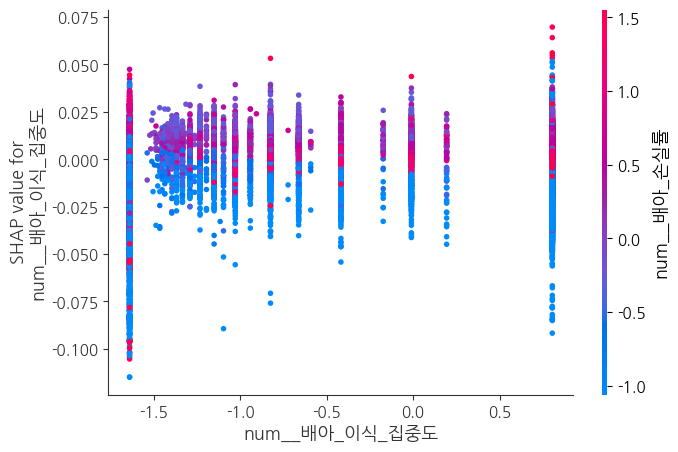

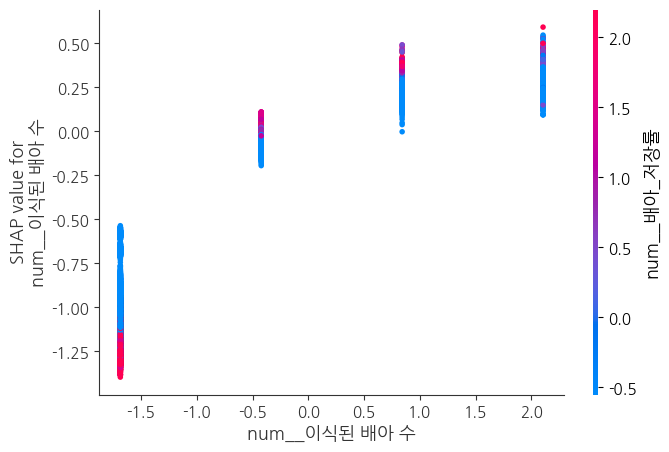

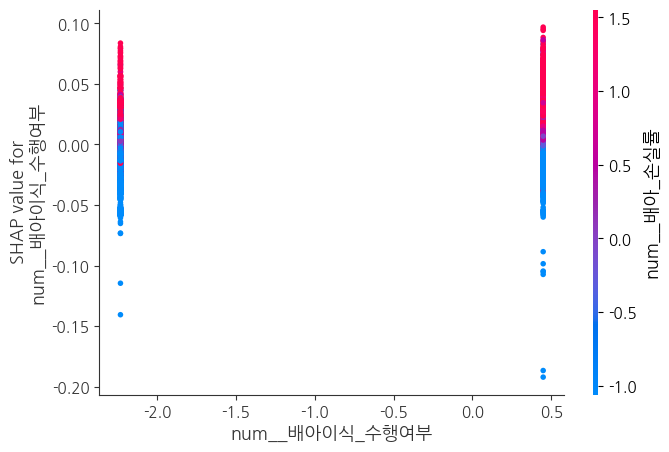

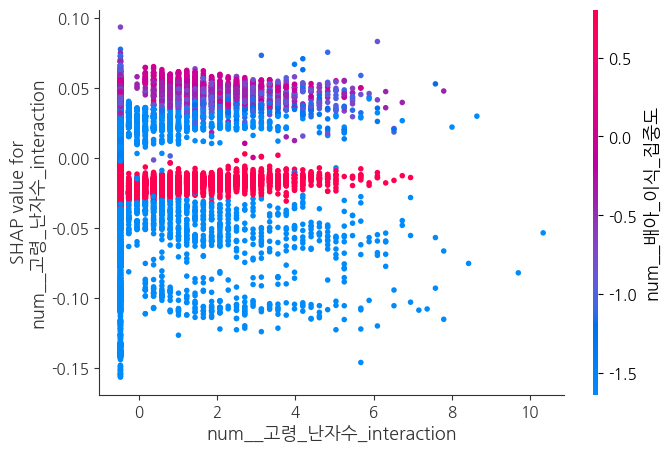

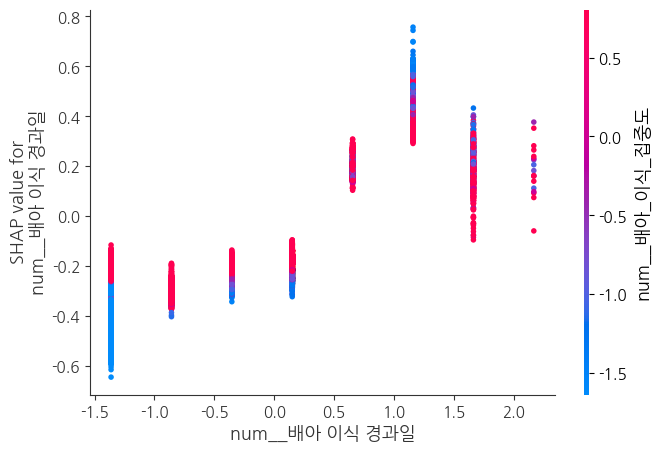

In [132]:
important_features = [
    "num__배아_이식_집중도",
    "num__이식된 배아 수",
    "num__배아이식_수행여부",
    "num__고령_난자수_interaction",
    "num__배아 이식 경과일",
]

X_test_dense = X_test_trans

if hasattr(X_test_dense, "toarray"):
    X_test_dense = X_test_dense.toarray()

feature_names = preprocessor.get_feature_names_out()

for feature in important_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_dense,
        feature_names=feature_names
    )

In [133]:
X_sub['다중_배아이식'] = (
    X_sub['이식된 배아 수'] >= 2
).astype(int)

X_sub['고도_시술진행군'] = (
    X_sub['시술_진행단계_수'] >= 3
).astype(int)

X_sub['적극_배아이식군'] = (
    X_sub['배아_이식_집중도'] >= 0.7
).astype(int)

In [134]:
numeric_features = X_sub.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_sub.select_dtypes(include="category").columns.tolist()

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

data_split = make_data_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42,
)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

cat_model.fit(
    X_train_trans,
    y_train,
    eval_set=(X_test_trans, y_test),
    early_stopping_rounds=50
)

y_pred = cat_model.predict(X_test_trans)
y_proba = cat_model.predict_proba(X_test_trans)[:, 1]

print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_proba))

0:	learn: 0.6856922	test: 0.6798887	best: 0.6798887 (0)	total: 285ms	remaining: 4m 44s
100:	learn: 0.7064899	test: 0.6999482	best: 0.7001372 (97)	total: 2.85s	remaining: 25.3s
200:	learn: 0.7100536	test: 0.7010799	best: 0.7013299 (191)	total: 6.4s	remaining: 25.4s
300:	learn: 0.7123732	test: 0.7023565	best: 0.7024202 (291)	total: 9.59s	remaining: 22.3s
400:	learn: 0.7147911	test: 0.7028650	best: 0.7036108 (367)	total: 12.5s	remaining: 18.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7036107663
bestIteration = 367

Shrink model to first 368 iterations.
f1: 0.5154065834961672
precision: 0.3856853629274145
recall: 0.7766118073380643
roc_auc: 0.7368557046683388


In [135]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_model.feature_importances_
})

importance_df.sort_values("importance", ascending=False).head(30)

,feature,importance
50,num__배아_이식_집중도,23.438034
13,num__이식된 배아 수,18.151463
47,num__배아이식_수행여부,12.548886
131,cat__난자 출처_본인 제공,5.066787
49,num__고령_난자수_interaction,4.190144
10,num__총 생성 배아 수,3.448005
26,num__배아 이식 경과일,2.641816
19,num__수집된 신선 난자 수,2.204692
136,cat__정자 출처_배우자 제공,1.929564
46,num__총_배아_활용량,1.731428


In [142]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__depth": [4, 5, 6, 7],
    "model__learning_rate": [0.03, 0.05, 0.07],
    "model__l2_leaf_reg": [3, 5, 7, 9],
    "model__iterations": [300, 500],
}

search = RandomizedSearchCV(
    estimator=cat_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_sub, y_sub)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__depth=5, model__iterations=300, model__l2_leaf_reg=9, model__learning_rate=0.03; total time= 6.0min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=3, model__learning_rate=0.05; total time= 6.5min
[CV] END model__depth=5, model__iterations=300, model__l2_leaf_reg=9, model__learning_rate=0.03; total time= 6.4min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=7, model__learning_rate=0.07; total time= 6.5min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=3, model__learning_rate=0.05; total time= 6.6min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=7, model__learning_rate=0.07; total time= 6.6min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=5, model__learning_rate=0.07; total time= 6.6min
[CV] END model__depth=7, model__iterations=300, model__l2_leaf_reg=7, model__learning_rate=0.07; total time= 6.6min
[CV] END mo

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__depth': [4, 5, ...], 'model__iterations': [300, 500], 'model__l2_leaf_reg': [3, 5, ...], 'model__learning_rate': [0.03, 0.05, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [143]:
print("Best Score:", search.best_score_)
print("Best Params:", search.best_params_)

Best Score: 0.517059203787733
Best Params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 3, 'model__iterations': 300, 'model__depth': 7}


In [144]:
pd.DataFrame(search.cv_results_)[
    [
        'mean_test_score',
        'std_test_score',
        'param_model__depth',
        'param_model__learning_rate',
        'param_model__l2_leaf_reg',
        'param_model__iterations'
    ]
].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_model__depth,param_model__learning_rate,param_model__l2_leaf_reg,param_model__iterations
2,0.517059,0.000934,7,0.05,3,300
1,0.517030,0.000180,7,0.07,5,300
5,0.516880,0.000590,7,0.05,7,300
3,0.516822,0.000354,7,0.05,9,500
7,0.516815,0.000528,5,0.03,7,500
6,0.516729,0.000726,6,0.03,9,500
0,0.516473,0.000220,7,0.07,7,300
9,0.516157,0.000400,4,0.05,9,300
4,0.515604,0.000765,5,0.03,9,300
8,0.514928,0.000533,4,0.03,3,300


In [146]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np

X_train, X_valid, y_train, y_valid = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42
)

best_model = search.best_estimator_
best_model.fit(X_train, y_train)

proba = best_model.predict_proba(X_valid)[:, 1]

best_f1 = 0
best_t = 0

for t in np.arange(0.20, 0.80, 0.01):
    pred = (proba >= t).astype(int)
    score = f1_score(y_valid, pred)

    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.49000000000000027
Best F1: 0.5155270376175548


AssertionError: 'shap_values' must have the same number of columns as 'features'!

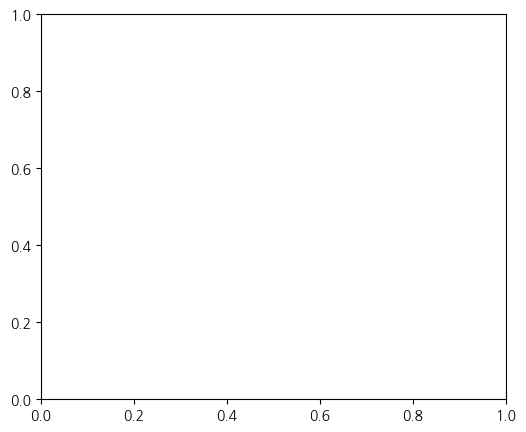

In [150]:
shap.dependence_plot(
    "num__배아_이식_집중도",
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    interaction_index=None
)